<a href="https://colab.research.google.com/github/Fata-Haidar/PCVK_Ganjil_2026/blob/main/pertemuan3/PCVK_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

**Transformasi Linier Brightness**

Mengubah tingkat kecerahan citra
---------------------------------
Masukkan nilai kecerahan: 30


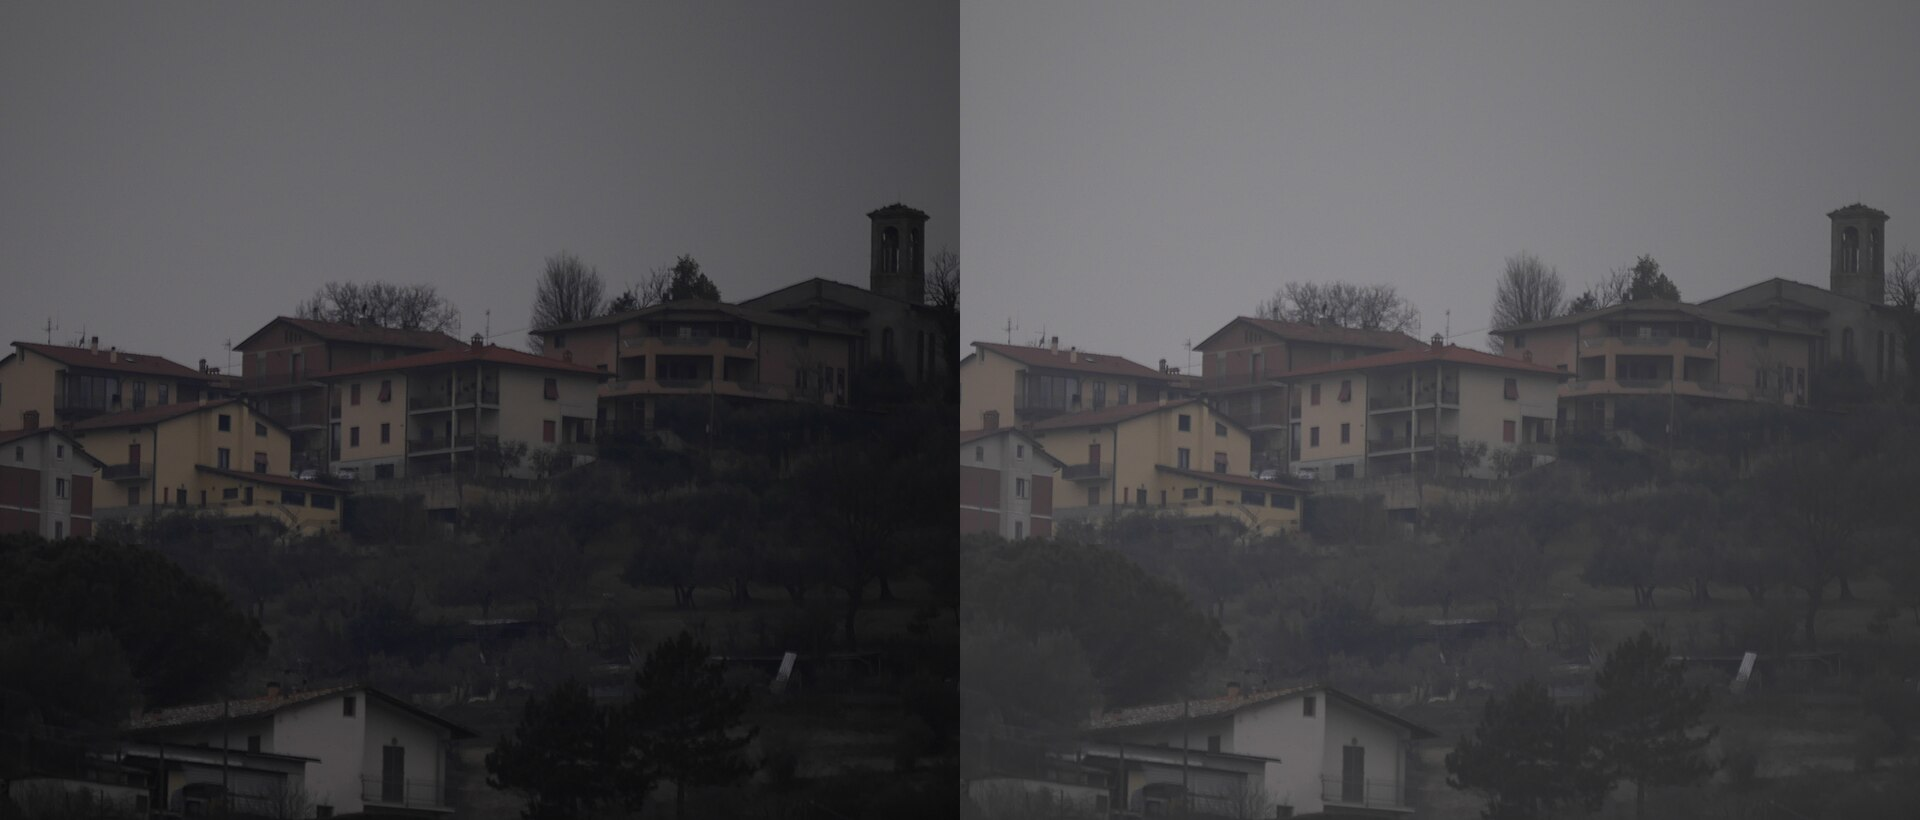

In [47]:
print('Mengubah tingkat kecerahan citra')
print('---------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, input harus berupa angka')
    brightness = 0


# Sesuaikan dengan lokasi file gambar Anda
original = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')


# Membuat array kosong untuk gambar hasil
brightness_image = np.zeros(original.shape, original.dtype)


# Akses setiap piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            # Transformasi brightness
            brightness_image[y, x, c] = np.clip(
                original[y, x, c] + brightness,
                0,
                255
            )


# Cara sederhana menggunakan OpenCV:
# brightness_image = cv.convertScaleAbs(original, beta=brightness)


# Menggabungkan gambar asli dan hasil brightness
final_frame = cv.hconcat((original, brightness_image))


# Menampilkan hasil
cv2_imshow(final_frame)




**TUGAS PRAKTIKUM**

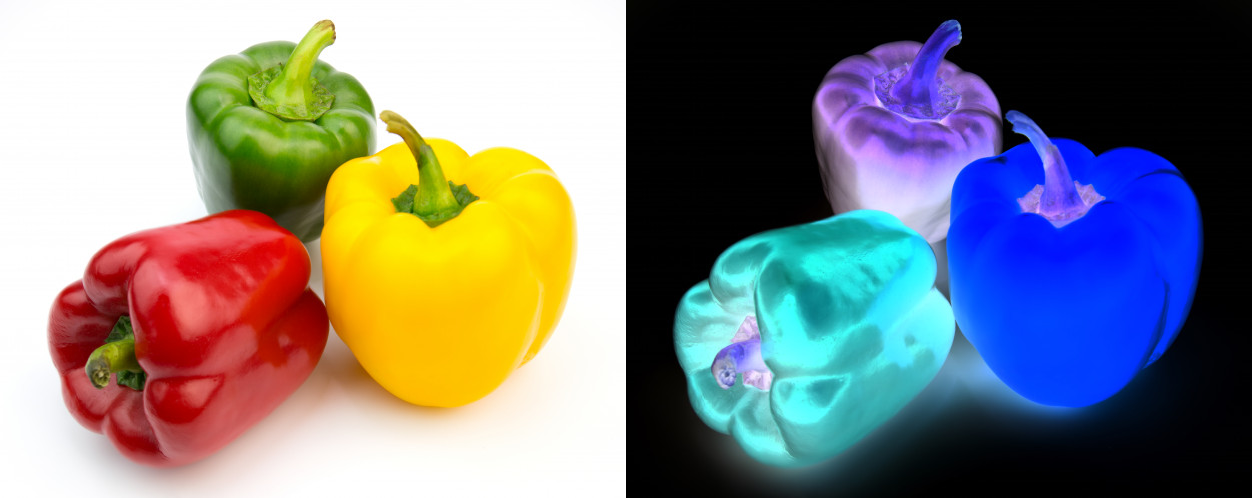

In [8]:
original = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')

inverse_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
          inverse_image[y, x, c] = 255 - original[y, x, c]

final_frame = cv.hconcat((original, inverse_image))

cv2_imshow(final_frame)

In [ ]:
# Implementasi Transformasi Contrast
# Formula: g(x,y) = alpha(f(x,y)-128)+128+beta
print("Mengubah kontras dan tingkat kecerahan citra")
print("---------------------------------------------")

# Input brightness dan contrast
brightness = int(input("Masukkan tingkat kecerahan: "))
contrast = float(input("Masukkan nilai kontras: "))


# Membaca gambar
original = cv.imread('/content/drive/MyDrive/KULIAH/PCVK/Images/houses.jpg')


# Membuat array hasil
contrast_image = np.zeros(original.shape, original.dtype)


# Proses transformasi piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            contrast_image[y,x,c] = np.clip(
                contrast * (original[y,x,c] - 128) + 128 + brightness,
                0,
                255
            )


# Menggabungkan gambar asli dan hasil
final_frame = cv.hconcat((original, contrast_image))


# Menampilkan hasil
cv2_imshow(final_frame)

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 50


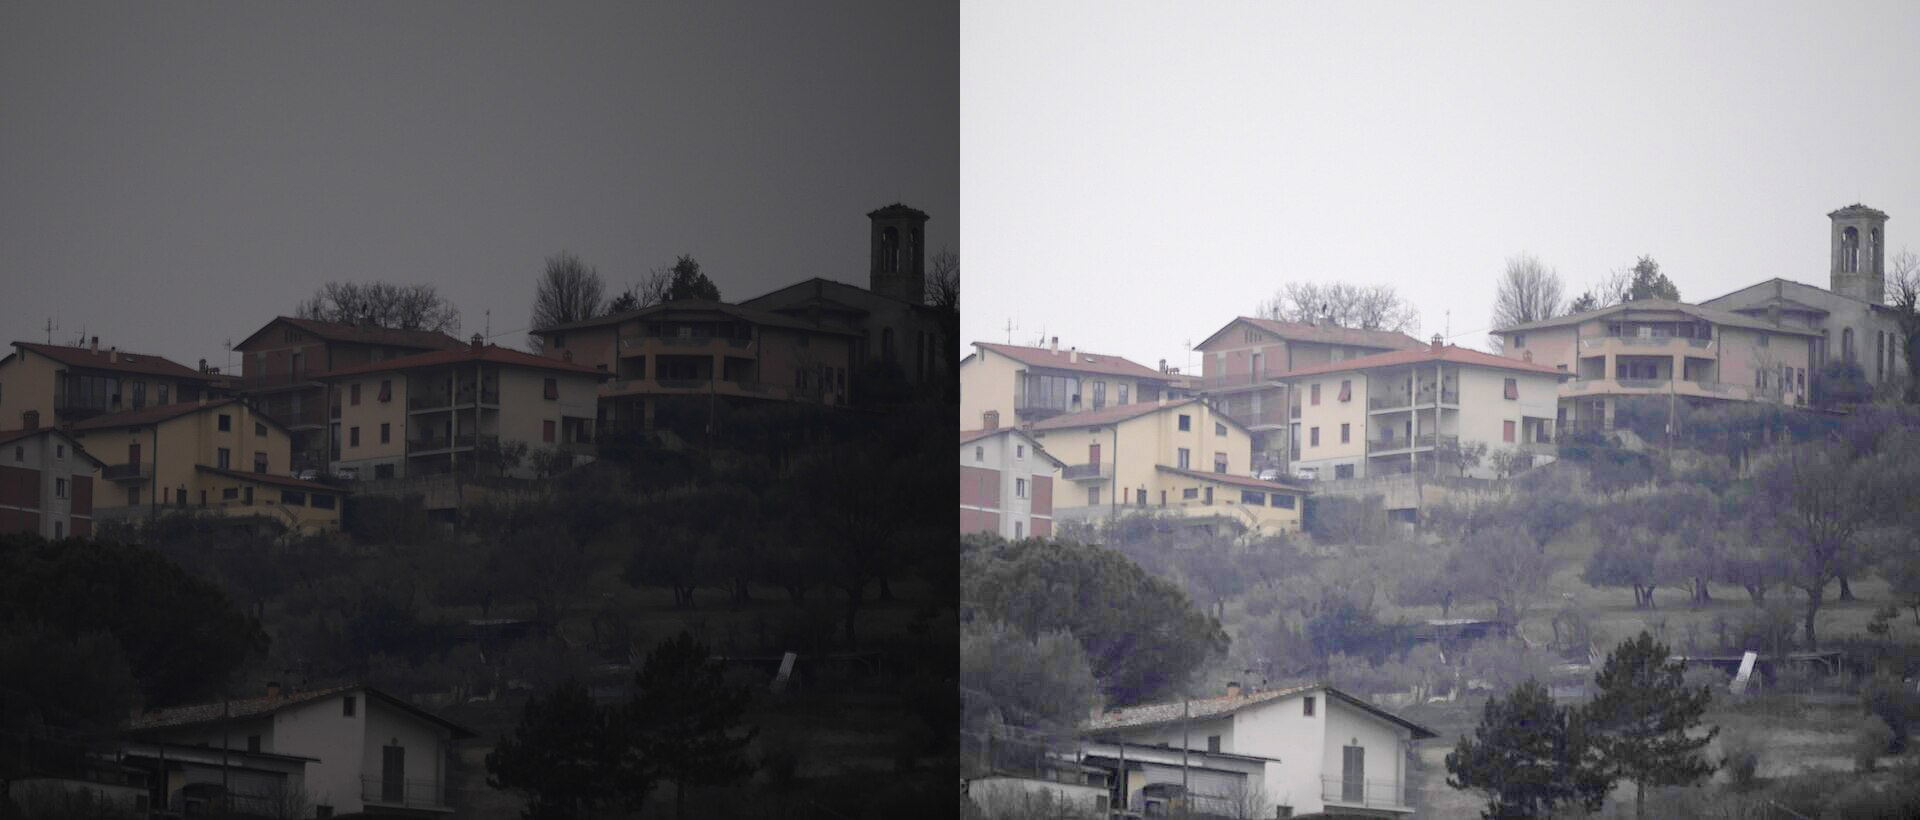

In [9]:
# Implementasi Transformasi Logarithmic Brightness
print("Mengubah tingkat kecerahan citra dengan Transformasi Log")
print("--------------------------------------------------------")


# Input nilai brightness
brightness = int(input("Masukkan nilai kecerahan: "))


# Membaca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')


# Konversi ke float agar perhitungan log akurat
image_float = original.astype(float)


# Konstanta c
c = brightness


# Transformasi logarithmic
log_image = c * np.log(1 + image_float)


# Normalisasi nilai agar berada pada range 0-255
log_image = cv.normalize(
    log_image,
    None,
    0,
    255,
    cv.NORM_MINMAX
)


# Ubah tipe data menjadi uint8
log_image = np.uint8(log_image)


# Gabungkan gambar asli dan hasil transformasi
final_frame = cv.hconcat((original, log_image))


# Tampilkan hasil
cv2_imshow(final_frame)


a. Averaging


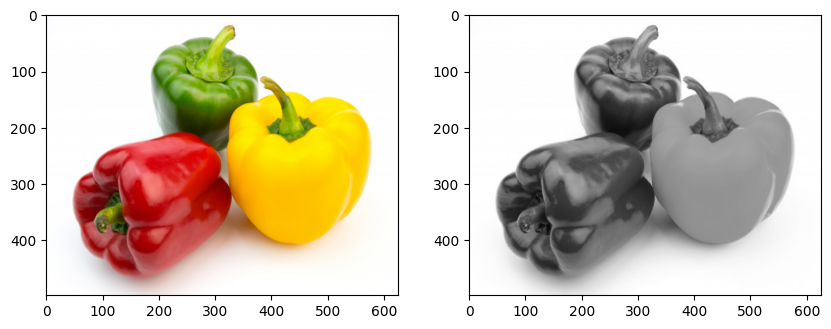

b. Lightness


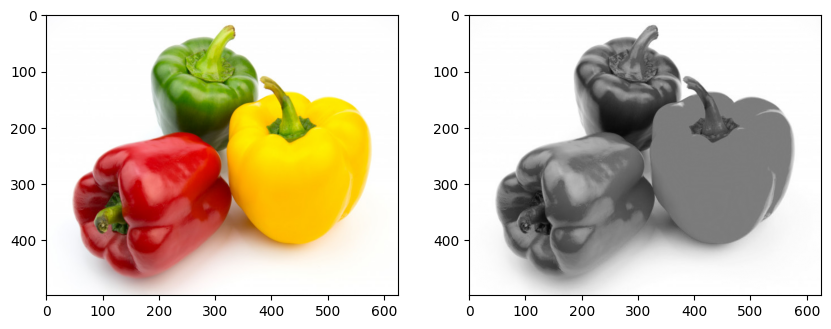

c. Luminance


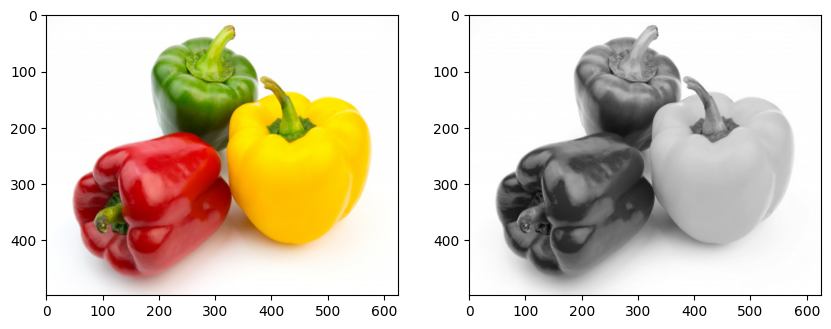

In [24]:
# 1. Baca gambar
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')

# Ubah BGR (default OpenCV) ke RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Ambil channel R, G, B
R = img_rgb[:, :, 0].astype(np.float32)
G = img_rgb[:, :, 1].astype(np.float32)
B = img_rgb[:, :, 2].astype(np.float32)

# 2. Hitung Formula Grayscale
# a. Averaging
gray_averaging = ((R + G + B) / 3).astype(np.uint8)

# b. Lightness
gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

# c. Luminance
gray_luminance = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

# 3. Fungsi untuk menampilkan 2 gambar bersandingan
def tampilkan_hasil(img_asli, img_gray, judul):
    print(f"{judul}")
    plt.figure(figsize=(10, 5))

    # Gambar Asli
    plt.subplot(1, 2, 1)
    plt.imshow(img_asli)

    # Gambar Grayscale
    plt.subplot(1, 2, 2)
    plt.imshow(img_gray, cmap='gray')

    plt.show()

# 4. Tampilkan Hasil
tampilkan_hasil(img_rgb, gray_averaging, "a. Averaging")
tampilkan_hasil(img_rgb, gray_lightness, "b. Lightness")
tampilkan_hasil(img_rgb, gray_luminance, "c. Luminance")

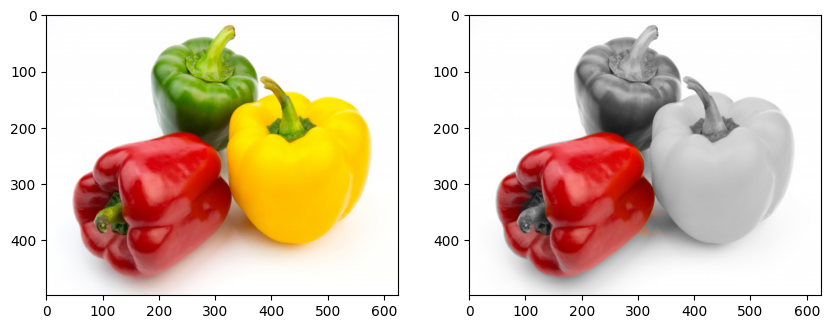

In [26]:
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# 2. Konversi ke ruang warna HSV untuk segmentasi warna
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

# 3. Buat mask untuk rentang warna MERAH dalam HSV
# (Merah berada di rentang bawah dan atas Hue)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)

lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])
mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)

# Gabungkan kedua mask merah
mask_red = cv.bitwise_or(mask1, mask2)

# 4. Buat versi grayscale dari gambar (3 channel agar bentuk matriksnya sama)
gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

# 5. Gabungkan warna asli (pada area mask merah) dan grayscale (pada area non-merah)
result = np.where(mask_red[:, :, np.newaxis] > 0, img_rgb, gray_3ch)

# 6. Tampilkan gambar asli dan hasil pengolahan bersandingan
plt.figure(figsize=(10, 5))

# Gambar Asli
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)

# Gambar Hasil Color Splash
plt.subplot(1, 2, 2)
plt.imshow(result)

plt.show()

Gamma Correction pada citra
----------------------------
Masukkan nilai Gamma: 0.5


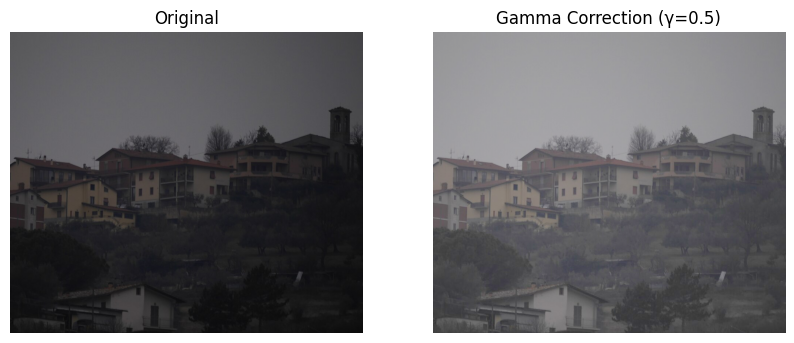

In [28]:
print('Gamma Correction pada citra')
print('----------------------------')


# Input nilai gamma
try:
    gamma = float(input('Masukkan nilai Gamma: '))

except ValueError:
    print('Error, not a number')
    gamma = 1



# Membaca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')


# Konversi BGR ke RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)



# Normalisasi piksel 0-1
normalized = img_rgb / 255.0


# Gamma correction
gamma_image = np.power(normalized, gamma)


# Kembalikan ke range 0-255
gamma_image = np.uint8(gamma_image * 255)



# Menampilkan hasil
plt.figure(figsize=(10,5))


plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(gamma_image)
plt.title(f"Gamma Correction (γ={gamma})")
plt.axis("off")


plt.show()

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


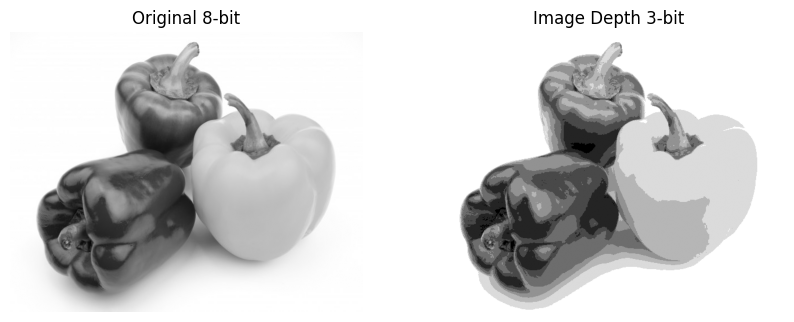

In [30]:
# Input bit depth
bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))


# Informasi bit
print("Bit depth awal  : 8 bit")
print("Bit depth tujuan:", bit_depth, "bit")


# Jumlah level
levels = 2 ** bit_depth

print("Jumlah level    :", levels)



# Baca gambar grayscale
original = cv.imread(
    '/content/drive/MyDrive/PCVK/peppers.jpg',
    cv.IMREAD_GRAYSCALE
)


# Kuantisasi
depth_image = np.zeros(original.shape, dtype=np.uint8)


# Faktor kuantisasi
factor = 256 / levels


# Proses setiap piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):

        depth_image[y,x] = (
            original[y,x] // factor
        ) * factor



# Tampilkan hasil
plt.figure(figsize=(10,5))


plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original 8-bit")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(depth_image, cmap='gray')
plt.title(f"Image Depth {bit_depth}-bit")
plt.axis("off")


plt.show()

Jumlah citra noise : 100


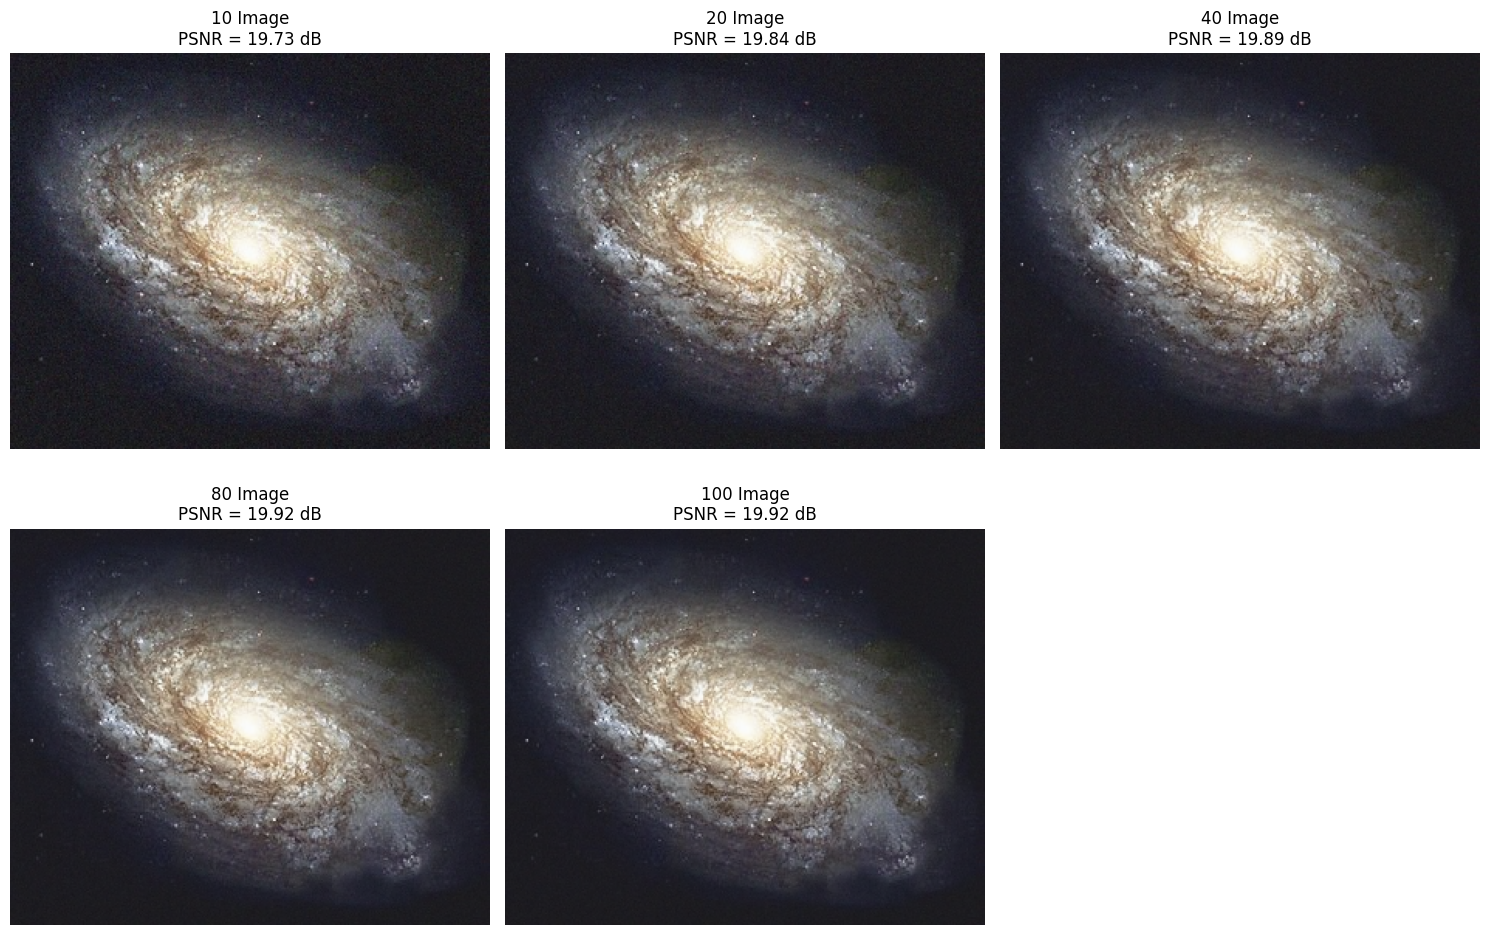


Hasil PSNR
-------------------------
Jumlah Citra | PSNR (dB)
     10      | 19.73
     20      | 19.84
     40      | 19.89
     80      | 19.92
    100      | 19.92


In [34]:
# 1. Membaca gambar asli
original = cv.imread(
    '/content/drive/MyDrive/PCVK/galaxy.jpg'
)
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# 2. Membaca semua gambar noise
cv_img = []

for img in glob.glob(
    '/content/drive/MyDrive/PCVK/noises/*.jpg'
):

    n = cv.imread(img)

    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)

    cv_img.append(n)


print("Jumlah citra noise :", len(cv_img))

# 3. Fungsi Average Denoising
def average_denoising(images):

    # membuat array kosong
    avg = np.zeros(
        images[0].shape,
        dtype=np.float32
    )


    # menjumlahkan semua gambar
    for img in images:
        avg += img.astype(np.float32)


    # rata-rata
    avg = avg / len(images)


    # kembali ke uint8
    return avg.astype(np.uint8)

# 4. Fungsi PSNR
def calculate_psnr(original, result):

    mse = np.mean(
        (original.astype(float) -
         result.astype(float)) ** 2
    )


    if mse == 0:
        return 100


    max_pixel = 255


    psnr = 10 * np.log10(
        (max_pixel ** 2) / mse
    )


    return psnr

# 5. Percobaan jumlah citra
jumlah_citra = [10,20,40,80,100]


nilai_psnr = []



plt.figure(figsize=(15,10))


for i, jumlah in enumerate(jumlah_citra):


    # mengambil sejumlah gambar noise
    data = cv_img[:jumlah]


    # average denoising
    hasil = average_denoising(data)


    # menghitung PSNR
    psnr = calculate_psnr(
        original,
        hasil
    )


    nilai_psnr.append(psnr)


    # menampilkan hasil
    plt.subplot(2,3,i+1)

    plt.imshow(hasil)

    plt.title(
        f"{jumlah} Image\nPSNR = {psnr:.2f} dB"
    )

    plt.axis("off")



plt.tight_layout()

plt.show()

# 6. Menampilkan tabel hasil
print("\nHasil PSNR")
print("-------------------------")

print("Jumlah Citra | PSNR (dB)")


for jumlah, psnr in zip(
    jumlah_citra,
    nilai_psnr
):

    print(
        f"{jumlah:^12} | {psnr:.2f}"
    )

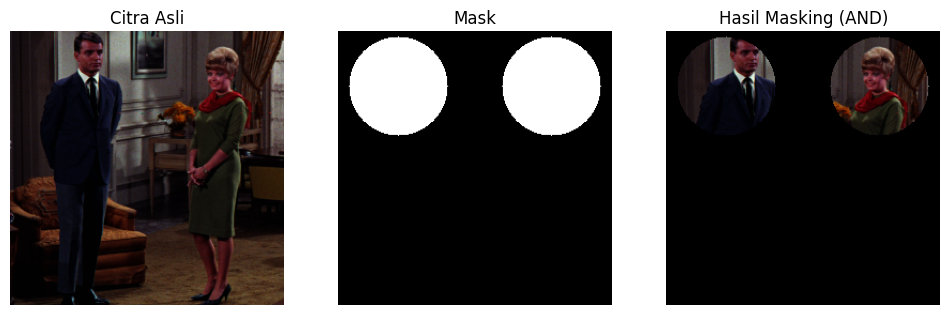

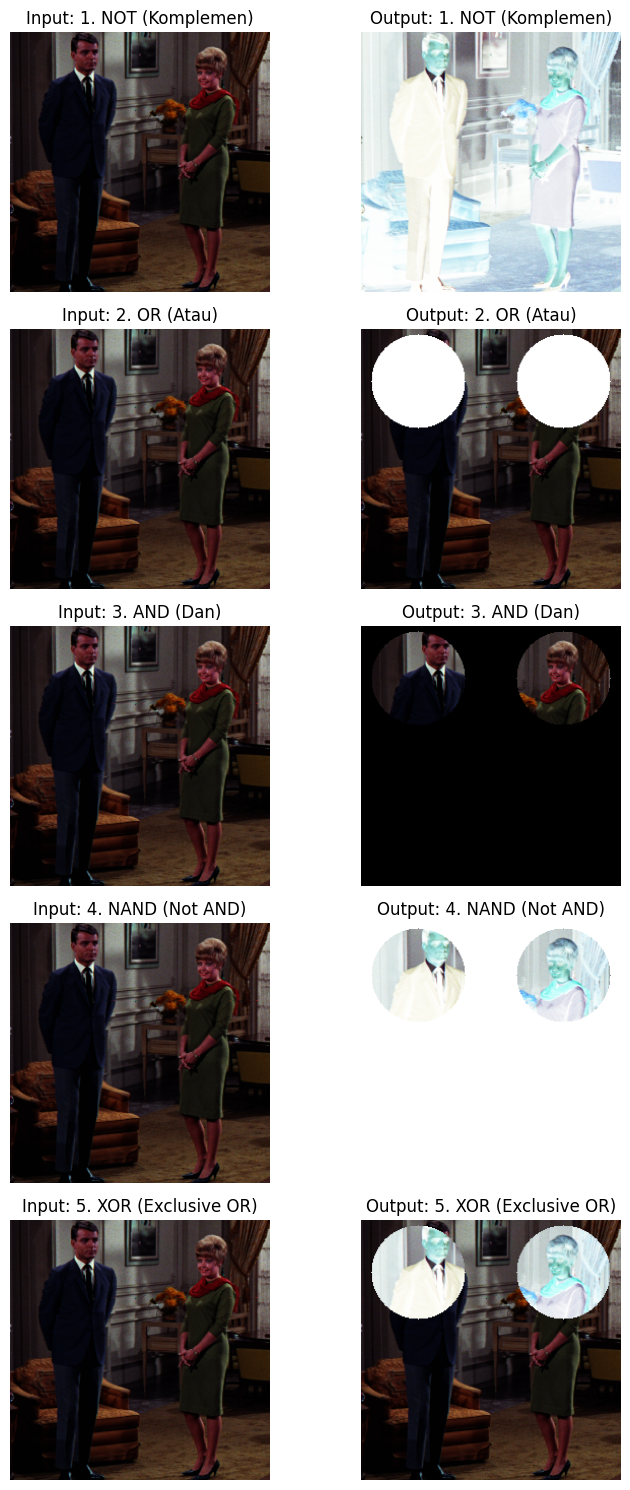

In [36]:
# 1. Baca Citra Asli (sesuaikan path gambar)
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/couple.tiff')

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
h, w, c = img_rgb.shape

# 2. Buat Mask Lingkaran Berwarna Putih (255) dengan Latar Hitam (0)
mask = np.zeros((h, w), dtype=np.uint8)

# Posisi dua lingkaran (sesuaikan koordinat pusat & radius jika perlu)
cv.circle(mask, (int(w * 0.22), int(h * 0.2)), int(min(h, w) * 0.18), 255, -1) # Lingkaran Pria
cv.circle(mask, (int(w * 0.78), int(h * 0.2)), int(min(h, w) * 0.18), 255, -1) # Lingkaran Wanita

# 3. Pengolahan Operasi Logika Bitwise
# a. AND (Masking standar: mengambil area di dalam lingkaran)
res_and = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

# b. NOT / Komplemen (Membalik warna citra asli)
res_not = cv.bitwise_not(img_rgb)

# c. OR (Menggabungkan citra dengan mask)
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)
res_or = cv.bitwise_or(img_rgb, mask_3ch)

# d. NAND (Kebalikan dari AND: NOT(AND))
res_nand = cv.bitwise_not(res_and)

# e. XOR (Exclusive OR)
res_xor = cv.bitwise_xor(img_rgb, mask_3ch)

# 4. Tampilkan Gambar Utama (Image Masking)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(res_and)
plt.title('Hasil Masking (AND)')
plt.axis('off')
plt.show()

# 5. Tampilkan Tabel Hasil Percobaan Operator
fig, axes = plt.subplots(5, 2, figsize=(8, 15))
ops = [
    ("1. NOT (Komplemen)", img_rgb, res_not),
    ("2. OR (Atau)", img_rgb, res_or),
    ("3. AND (Dan)", img_rgb, res_and),
    ("4. NAND (Not AND)", img_rgb, res_nand),
    ("5. XOR (Exclusive OR)", img_rgb, res_xor)
]

for idx, (title, img_in, img_out) in enumerate(ops):
    axes[idx, 0].imshow(img_in)
    axes[idx, 0].set_title(f"Input: {title}")
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(img_out)
    axes[idx, 1].set_title(f"Output: {title}")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

Masukkan nilai gamma: 0.4


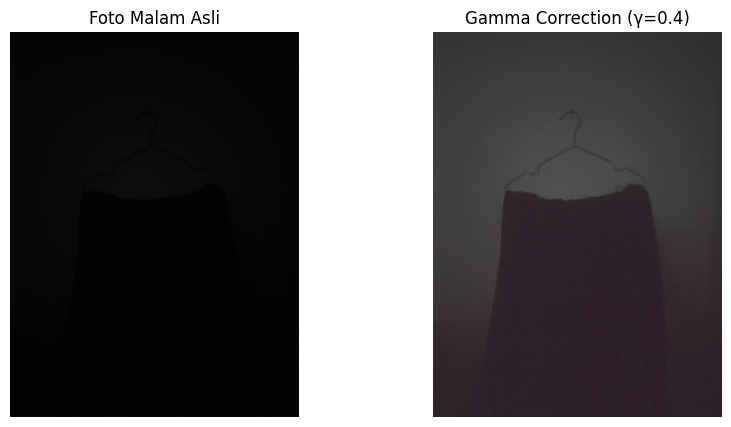

In [43]:
# Membaca foto malam
img = cv.imread('/content/drive/MyDrive/PCVK/gelap.jpg')


# Konversi BGR ke RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)


# Input nilai gamma
gamma = float(input("Masukkan nilai gamma: "))


# Normalisasi pixel
normalized = img_rgb / 255.0


# Gamma Correction
gamma_image = np.power(normalized, gamma)


# Kembalikan ke range 0-255
gamma_image = np.uint8(gamma_image * 255)



# Menampilkan hasil
plt.figure(figsize=(10,5))


plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Foto Malam Asli")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(gamma_image)
plt.title(f"Gamma Correction (γ={gamma})")
plt.axis("off")


plt.show()

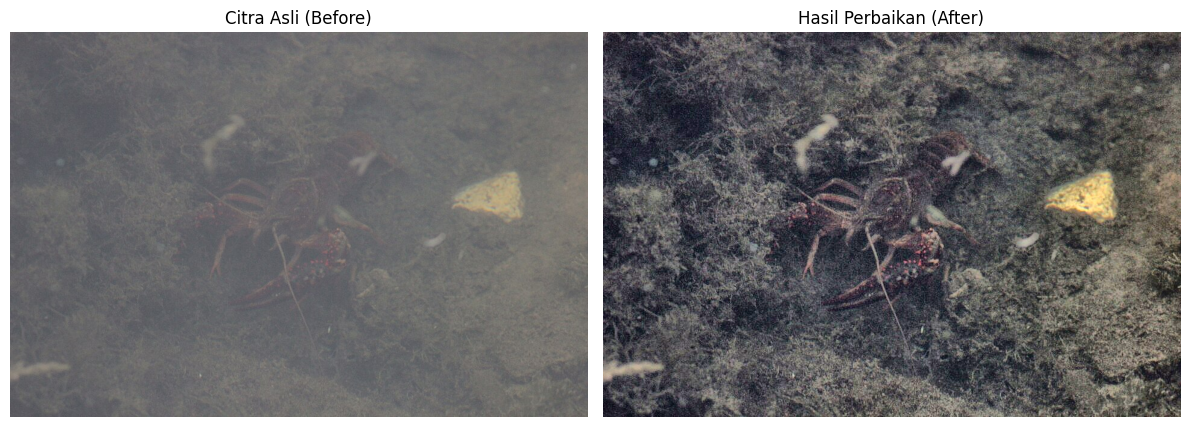

In [45]:
# 1. Baca Citra Asli
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/crayfish.jpg')
if img_bgr is None:
    # Menggunakan dummy jika file belum ada
    img_bgr = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# 2. METODE 1: Contrast Stretching (Peregangan Kontras)
# Mengubah distribusi intensitas agar memenuhi rentang penuh [0, 255]
r_min, r_max = np.min(img_rgb), np.max(img_rgb)
img_stretched = ((img_rgb - r_min) / (r_max - r_min) * 255).astype(np.uint8)

# 3. METODE 2: CLAHE pada Ruang Warna LAB (Perbaikan Kontras Adaptif)
# Konversi ke ruang warna LAB agar pencerahan tidak merusak tone warna
lab = cv.cvtColor(img_stretched, cv.COLOR_RGB2LAB)
l, a, b = cv.split(lab)

# Terapkan CLAHE pada channel L (Luminance)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl = clahe.apply(l)

# Gabungkan kembali channel dan konversi ke RGB
limg = cv.merge((cl, a, b))
img_final = cv.cvtColor(limg, cv.COLOR_LAB2RGB)

# 4. Tampilkan Before - After
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli (Before)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_final)
plt.title('Hasil Perbaikan (After)')
plt.axis('off')

plt.tight_layout()
plt.show()